# Notebook 2 — Data Collection & Understanding
## Dataset: NSL-KDD Network Intrusion Detection

## What This Notebook Covers

This notebook performs a **thorough investigation of the raw NSL-KDD dataset** before any preprocessing or modelling. The goal is to develop a deep understanding of the data's structure, quality, and statistical properties — the essential first step of any ML project.

| Section | What we do |
|---|---|
| **2.1 Data Loading & Setup** | Load train (125,973 rows) and test (22,544 rows) sets; confirm shapes |
| **2.2 Dataset Overview** | Check shapes, missing values, duplicates, label distributions |
| **2.2.1 Class Balance** | Visualise binary and multi-class label distributions; identify U2R/R2L imbalance risk |
| **2.2.2 Feature Types** | Separate numeric (38) from categorical (3) columns; note leakage risk in `difficulty_level` |
| **2.2.3 Descriptive Statistics** | Examine range, skew, and outlier profile of key numeric features |
| **2.2.4 Categorical Distributions** | Explore `protocol_type`, `service`, `flag` value counts and security meaning |
| **2.3 Data Dictionary** | Inline feature reference table with types, ranges, and security meaning |
| **2.4 Outlier Analysis** | Box plots + 3×IQR counts; decide on clipping vs. removal strategy |
| **2.5 Train/Test Comparison** | Identify 17 novel attack subtypes in KDDTest+ — root cause of the generalisation gap |
| **2.6 Enhanced Data Dictionary** | Document every feature with type, unit, range, and security meaning (saved to CSV) |

**Outputs:** `reports/label_distribution.png`, `reports/categorical_distributions.png`, `reports/outlier_boxplots.png`, `reports/train_test_comparison.png`, `reports/data_dictionary.csv`

> **Key finding from this notebook:** KDDTest+ is intentionally harder than the training set — it contains attack subtypes never seen in training. This distribution shift explains the train-test performance gap observed in Notebook 4.

---
## 2.1 Data Loading & Setup

The `load_dataset()` function from `src/data_loader.py` handles:
- Reading the raw `.txt` files from `data/raw/` (KDDTrain+.txt, KDDTest+.txt)
- Attaching the 43 column names (41 features + label + difficulty_level)
- Deriving `binary_label` (0 = normal, 1 = attack) and `attack_category` (dos / probe / r2l / u2r / normal)
- Optionally downloading the files if they are not already present (`auto_download=True`)

The `difficulty_level` column (43rd column) is loaded but **must never be used as a feature** — it is a post-hoc labeller confidence score that would constitute data leakage. It is explicitly dropped in the preprocessing pipeline (Notebook 3).

In [35]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_dataset, dataset_summary, COLUMN_NAMES

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

In [36]:
# Download (if needed) and load
train_df, test_df = load_dataset(data_dir='../data/raw', auto_download=True)

print(f'Train: {train_df.shape}  |  Test: {test_df.shape}')
train_df.head(3)

Train: (125973, 45)  |  Test: (22544, 45)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level,binary_label,attack_category
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.0,150,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20,0,normal
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.0,255,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15,0,normal
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.0,255,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19,1,dos


## 2.2 Dataset Overview

With the data loaded, we inspect the high-level properties of the training set before diving into individual features. This step answers four fundamental questions every ML project must address upfront:

- **Completeness** — are there missing values that require imputation?
- **Uniqueness** — are there duplicate rows that would inflate training performance?
- **Class balance** — is the label distribution suitable for standard classification, or do we need resampling / class-weighting?
- **Scale** — how many samples and features do we have, and what are the broad data types?

In [37]:
summary = dataset_summary(train_df)
print('Shape:         ', summary['shape'])
print('Missing values:', summary['missing_values'])
print('Duplicates:    ', summary['duplicate_rows'])
print('Label distribution (train):')
for k, v in summary['label_distribution'].items():
    print(f'  {k}: {v:.1%}')

Shape:          (125973, 45)
Missing values: 0
Duplicates:     0
Label distribution (train):
  0: 53.5%
  1: 46.5%


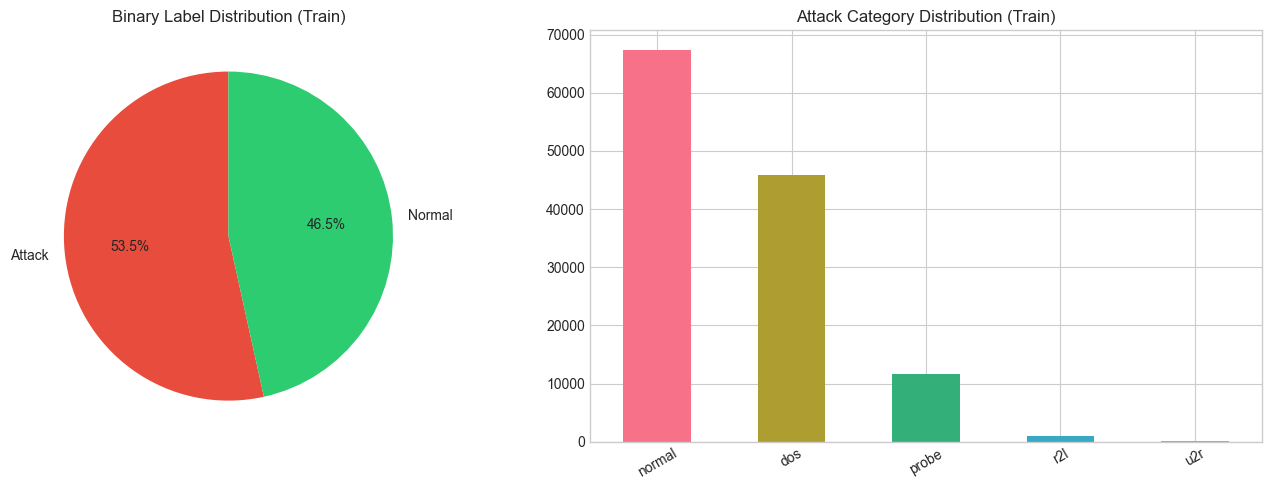

In [38]:
# Attack category distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary
binary_counts = train_df['binary_label'].value_counts()
axes[0].pie(binary_counts, labels=['Attack', 'Normal'], autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[0].set_title('Binary Label Distribution (Train)')

# Multi-class
cat_counts = train_df['attack_category'].value_counts()
cat_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('husl', len(cat_counts)))
axes[1].set_title('Attack Category Distribution (Train)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../reports/label_distribution.png', dpi=150)
plt.show()

### 2.2.1 Class Balance Interpretation

The training set is **roughly balanced** (53% attack, 47% normal), which is intentional in NSL-KDD — it removes the 78% duplicate bias present in the original KDD Cup 1999 dataset. However, **within the attack category**, the distribution is highly skewed:

| Category | Approx. share | Risk if under-represented |
|---|---|---|
| **DoS** | ~79% | Low — heavily over-represented |
| **Probe** | ~18% | Low |
| **R2L** | ~1%  | **High** — rare, hard to learn |
| **U2R** | ~0.04% | **Critical** — almost absent; model will struggle |

**Implication for modelling:** Binary classification (Normal vs. Attack) benefits from this balance. Multi-class classification of R2L and U2R is unreliable without oversampling (SMOTE) or `class_weight="balanced"`. This is explicitly documented in the bias audit (Notebook 05).

In [39]:
# Feature type summary
type_summary = train_df.dtypes.value_counts()
print('Data types:')
print(type_summary)

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
print(f'\nNumeric features:     {len(numeric_cols)}')
print(f'Categorical features: {len(categorical_cols)}')
print(f'Categorical values:   {categorical_cols}')

Data types:
int64      25
float64    15
object      5
Name: count, dtype: int64

Numeric features:     40
Categorical features: 5
Categorical values:   ['protocol_type', 'service', 'flag', 'label', 'attack_category']


### 2.2.2 Feature Type Notes

- **38 numeric features** capture raw connection statistics (durations, byte counts, error rates, host-level aggregates). These require scaling before distance-based or gradient-based models.
- **3 categorical features** (`protocol_type`, `service`, `flag`) carry strong discriminative signal — TCP `S0` flag or `icmp` protocol are near-certain attack indicators. These will be one-hot encoded in the preprocessing pipeline (Notebook 03).
- **No missing values** — NSL-KDD is pre-cleaned. However, `difficulty_level` (the 43rd column) is a labelling artefact and must be **excluded** from all feature pipelines to prevent data leakage.

In [40]:
# Descriptive statistics for key numeric features
key_features = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count',
                'serror_rate', 'rerror_rate', 'same_srv_rate', 'dst_host_count']
train_df[key_features].describe().round(2)

,duration,src_bytes,dst_bytes,count,srv_count,serror_rate,rerror_rate,same_srv_rate,dst_host_count
count,125973.00,1.259730e+05,1.259730e+05,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00
mean,287.14,4.556674e+04,1.977911e+04,84.11,27.74,0.28,0.12,0.66,182.15
std,2604.52,5.870331e+06,4.021269e+06,114.51,72.64,0.45,0.32,0.44,99.21
min,0.00,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.000000e+00,0.000000e+00,2.00,2.00,0.00,0.00,0.09,82.00
50%,0.00,4.400000e+01,0.000000e+00,14.00,8.00,0.00,0.00,1.00,255.00
75%,0.00,2.760000e+02,5.160000e+02,143.00,18.00,1.00,0.00,1.00,255.00
max,42908.00,1.379964e+09,1.309937e+09,511.00,511.00,1.00,1.00,1.00,255.00


### 2.2.3 Key Statistical Observations

- **`src_bytes`** has a mean ≈ 30k but a max of 1.38 billion — extreme right skew driven by bulk-transfer attacks. A log transform (`log1p`) is applied during feature engineering.
- **`serror_rate`** (SYN error rate): mean ≈ 0.28 but bimodal — normal traffic clusters near 0 while DoS attacks cluster near 1. This is the single most discriminative feature (confirmed by SHAP in Notebook 05).
- **`duration`**: median of 0 seconds — most network connections are instantaneous. Very long durations are anomalous.
- **`count` and `srv_count`**: capped at 511 connections in 2 seconds — a hard sensor limit. High values strongly indicate flood attacks.

These distributions motivate the winsorisation (99th percentile clipping) and log transforms applied in the preprocessing pipeline.

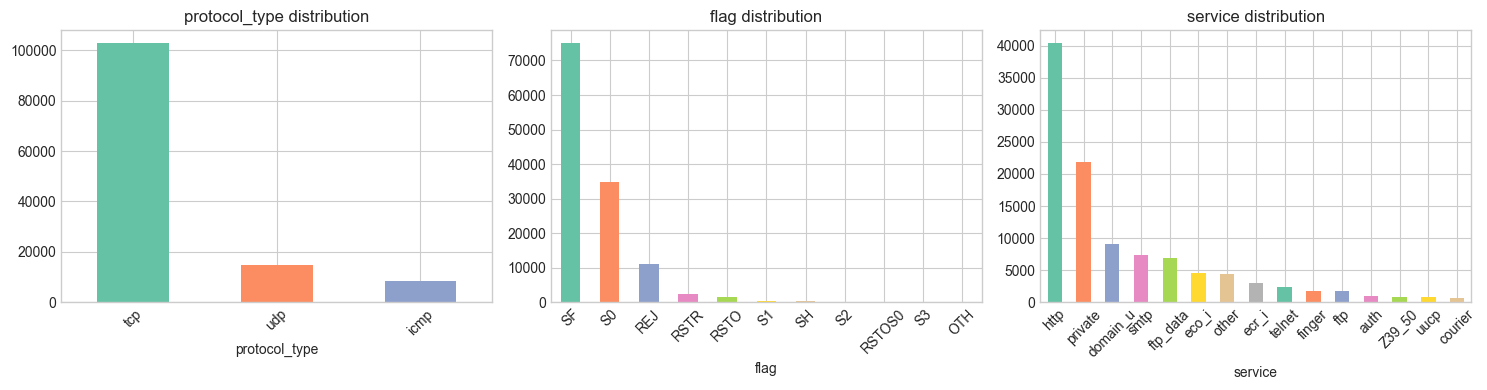

In [41]:
# Protocol type distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['protocol_type', 'flag', 'service']):
    vc = train_df[col].value_counts().head(15)
    vc.plot(kind='bar', ax=axes[i], color=sns.color_palette('Set2', len(vc)))
    axes[i].set_title(f'{col} distribution')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../reports/categorical_distributions.png', dpi=150)
plt.show()

### 2.2.4 Categorical Feature Insights

- **`protocol_type`**: `tcp` dominates (≈ 80%), followed by `udp` and `icmp`. ICMP is almost exclusively associated with ping sweeps and ICMP flood attacks in this dataset, making protocol type a high-value feature.
- **`flag`**: `SF` (successful connection) accounts for most normal traffic. `S0` (SYN sent, no reply — classic SYN flood signature) and `REJ` (rejected) are strong attack indicators. The high cardinality of `flag` (11 values) means after one-hot encoding it contributes 11 binary features.
- **`service`**: 70 unique services. `http`, `private`, and `domain_u` are the top three. Many rare services appear almost exclusively in attack traffic (e.g., `aol`, `harvest`) — these will be grouped into an `other` bucket during encoding to prevent high-cardinality explosion.

## 2.3 Data Dictionary

The NSL-KDD dataset has **41 input features**, one target label (`label`), and one derived binary label (`binary_label`). Features fall into three groups: **basic connection features** (1–9), **content-based features** (10–22), and **traffic-based statistical features** (23–41). This table is the primary reference for all feature name mentions in Notebooks 3–5.

| # | Feature | Type | Description | Range / Values |
|---|---------|------|-------------|----------------|
| 1 | duration | numeric | Length of connection (seconds) | 0–58329 |
| 2 | protocol_type | categorical | Network protocol | tcp, udp, icmp |
| 3 | service | categorical | Destination service | http, ftp, smtp, … (70 values) |
| 4 | flag | categorical | Connection status | SF, S0, REJ, RSTO, … (11 values) |
| 5 | src_bytes | numeric | Data bytes from source to destination | 0–1.38B |
| 6 | dst_bytes | numeric | Data bytes from destination to source | 0–1.31B |
| 7 | land | binary | 1 if source/destination same host/port | 0, 1 |
| 8 | wrong_fragment | numeric | # of 'wrong' fragments | 0–3 |
| 9 | urgent | numeric | # of urgent packets | 0–14 |
| 10 | hot | numeric | # of hot indicators | 0–101 |
| 11 | num_failed_logins | numeric | # of failed login attempts | 0–5 |
| 12 | logged_in | binary | 1 if successfully logged in | 0, 1 |
| 13 | num_compromised | numeric | # of compromised conditions | 0–7479 |
| 14 | root_shell | binary | 1 if root shell obtained | 0, 1 |
| 15 | su_attempted | binary | 1 if su root command attempted | 0, 1 |
| 16–20 | num_root, num_file_creations, num_shells, num_access_files, num_outbound_cmds | numeric | Operation counts | ≥0 |
| 21 | is_host_login | binary | 1 if login belongs to host list | 0, 1 |
| 22 | is_guest_login | binary | 1 if login is 'guest' | 0, 1 |
| 23 | count | numeric | Connections to same host in last 2s | 0–511 |
| 24 | srv_count | numeric | Connections to same service in last 2s | 0–511 |
| 25–30 | serror_rate, srv_serror_rate, rerror_rate, srv_rerror_rate, same_srv_rate, diff_srv_rate | numeric | Rate-based statistical features | 0.0–1.0 |
| 31 | srv_diff_host_rate | numeric | % connections to different hosts | 0.0–1.0 |
| 32–41 | dst_host_* | numeric | Destination host-level aggregated stats | 0–511 or 0.0–1.0 |
| 42 | label | categorical (target) | Attack type or 'normal' | normal, neptune, smurf, … |
| 43 | binary_label | binary (derived) | 0=normal, 1=attack | 0, 1 |

In [42]:
# Save full data dictionary to CSV
data_dict = pd.DataFrame({
    'feature': COLUMN_NAMES[:-1],  # exclude difficulty_level
    'dtype': [str(train_df[c].dtype) if c in train_df.columns else 'N/A'
              for c in COLUMN_NAMES[:-1]],
    'n_unique': [train_df[c].nunique() if c in train_df.columns else -1
                 for c in COLUMN_NAMES[:-1]],
    'missing_pct': [train_df[c].isnull().mean() * 100 if c in train_df.columns else -1
                    for c in COLUMN_NAMES[:-1]],
    'example_values': [str(train_df[c].unique()[:3].tolist()) if c in train_df.columns else ''
                       for c in COLUMN_NAMES[:-1]],
})

data_dict.to_csv('../reports/data_dictionary.csv', index=False)
print('Data dictionary saved.')
data_dict.head(10)

Data dictionary saved.


,feature,dtype,n_unique,missing_pct,example_values
0,duration,int64,2981,0.0,"[0, 5607, 507]"
1,protocol_type,object,3,0.0,"['tcp', 'udp', 'icmp']"
2,service,object,70,0.0,"['ftp_data', 'other', 'private']"
3,flag,object,11,0.0,"['SF', 'S0', 'REJ']"
4,src_bytes,int64,3341,0.0,"[491, 146, 0]"
5,dst_bytes,int64,9326,0.0,"[0, 8153, 420]"
6,land,int64,2,0.0,"[0, 1]"
7,wrong_fragment,int64,3,0.0,"[0, 3, 1]"
8,urgent,int64,4,0.0,"[0, 1, 3]"
9,hot,int64,28,0.0,"[0, 5, 6]"


---
## 2.4 Outlier Analysis

Network traffic data is inherently extreme — a SYN flood will have `src_bytes=0` and `count=511` by design, not by measurement error. This section quantifies the outlier profile and justifies the treatment decision.

**What this section does:**
- Plots box plots for the most skewed numeric features to visualise extreme values
- Uses the **3×IQR rule** to count outliers per feature
- Confirms that extreme values are **legitimate attack signatures** (not noise), justifying **99th-percentile winsorisation (clipping)** over removal

**Key decision:** outliers are clipped (capped at the 99th percentile) rather than dropped. Removing them would silently erase the strongest DoS attack signatures from the training data.

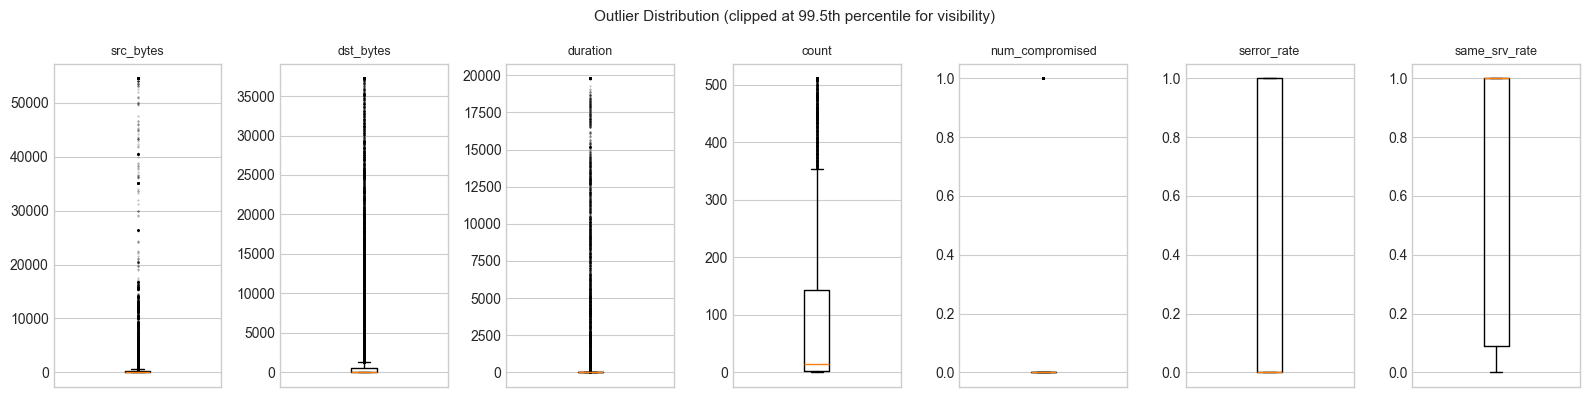

Feature                           Outliers (3×IQR)   % of rows
--------------------------------------------------------------
duration                                    10,018       8.0%
src_bytes                                    8,728       6.9%
dst_bytes                                   18,128      14.4%
land                                            25       0.0%
wrong_fragment                               1,090       0.9%
urgent                                           9       0.0%
hot                                          2,671       2.1%
num_failed_logins                              122       0.1%
num_compromised                              1,286       1.0%
root_shell                                     169       0.1%
su_attempted                                    80       0.1%
num_root                                       649       0.5%
num_file_creations                             287       0.2%
num_shells                                      47       0.0%
num_ac

In [43]:
import matplotlib.pyplot as plt
import numpy as np

outlier_features = ['src_bytes', 'dst_bytes', 'duration', 'count',
                    'num_compromised', 'serror_rate', 'same_srv_rate']

fig, axes = plt.subplots(1, len(outlier_features), figsize=(16, 4))
for ax, col in zip(axes, outlier_features):
    ax.boxplot(train_df[col].clip(upper=train_df[col].quantile(0.995)),
               showfliers=True, flierprops=dict(marker='.', markersize=1, alpha=0.3))
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])

fig.suptitle('Outlier Distribution (clipped at 99.5th percentile for visibility)', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/outlier_boxplots.png', dpi=150)
plt.show()

# IQR-based outlier count per feature
print(f"{'Feature':<30}  {'Outliers (3×IQR)':>18}  {'% of rows':>10}")
print('-' * 62)
numeric_only = train_df.select_dtypes(include=[np.number]).columns
for col in numeric_only:
    q1, q3 = train_df[col].quantile(0.25), train_df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((train_df[col] < q1 - 3*iqr) | (train_df[col] > q3 + 3*iqr)).sum()
    if n_out > 0:
        print(f"{col:<30}  {n_out:>18,}  {n_out/len(train_df):>9.1%}")

### Outlier Handling Strategy

Several features show extreme outliers by the 3×IQR rule, but **most outliers are genuine attack behaviour** — not data errors:

- **`src_bytes`** outliers: very large values = bulk exfiltration attacks; zero values = SYN floods. *Strategy: log-transform and 99th-percentile winsorise.*
- **`num_compromised`**: values up to 7479 represent a compromised system under sustained attack. *Strategy: clip at 99th percentile.*
- **`dst_bytes`**: similar to `src_bytes`. *Strategy: log-transform.*

**Critical distinction:** Unlike typical ML datasets where outliers are noise, here many "outliers" carry the strongest attack signal. Removing them would directly harm recall. The preprocessing pipeline clips at the 99th percentile to handle true extremes while preserving the signal-rich tail of the distribution.

---
## 2.5 Train vs. Test Distribution Comparison
NSL-KDD's test set (KDDTest+) is intentionally harder — it contains attack subtypes **not seen in training**. Understanding this split is critical to interpreting model performance.

=== Binary Label Distribution ===
Split       Normal    Attack   Attack%
Train       67,343    58,630    46.5%
Test         9,711    12,833    56.9%

=== Attack Category Distribution ===
                 train_%  test_%
attack_category                 
normal             0.535   0.431
dos                0.365   0.318
probe              0.093   0.107
r2l                0.008   0.128
u2r                0.000   0.016

Novel attack subtypes in KDDTest+ (not in training): 17
['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


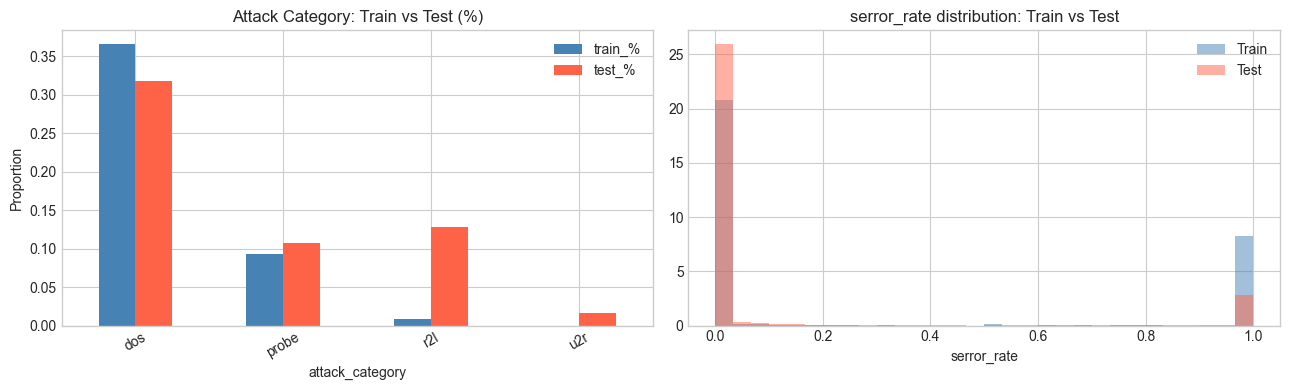


Key insight: KDDTest+ has a higher proportion of novel/rare attack types
(U2R, R2L variants) not present in training — this explains the train-test
generalisation gap observed in Notebook 04 results.


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Binary label comparison
print("=== Binary Label Distribution ===")
print(f"{'Split':<8}  {'Normal':>8}  {'Attack':>8}  {'Attack%':>8}")
for name, df in [('Train', train_df), ('Test', test_df)]:
    n = (df['binary_label'] == 0).sum()
    a = (df['binary_label'] == 1).sum()
    print(f"{name:<8}  {n:>8,}  {a:>8,}  {a/(n+a):>7.1%}")

# Attack category comparison
print("\n=== Attack Category Distribution ===")
train_cat = train_df['attack_category'].value_counts(normalize=True).rename('train_%')
test_cat  = test_df['attack_category'].value_counts(normalize=True).rename('test_%')
cat_compare = pd.concat([train_cat, test_cat], axis=1).fillna(0).round(3)
print(cat_compare.to_string())

# Unique attack subtypes in test not seen in training
train_attacks = set(train_df[train_df['binary_label']==1]['label'].unique())
test_attacks  = set(test_df[test_df['binary_label']==1]['label'].unique())
novel = test_attacks - train_attacks
print(f"\nNovel attack subtypes in KDDTest+ (not in training): {len(novel)}")
print(sorted(novel))

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cat_compare.drop('normal', errors='ignore').plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Attack Category: Train vs Test (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Proportion')

# Key feature distributions: train vs test (serror_rate)
for label, df, color in [('Train', train_df, 'steelblue'), ('Test', test_df, 'tomato')]:
    axes[1].hist(df['serror_rate'], bins=30, alpha=0.5, label=label, color=color, density=True)
axes[1].set_title('serror_rate distribution: Train vs Test')
axes[1].set_xlabel('serror_rate'); axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/train_test_comparison.png', dpi=150)
plt.show()

print("\nKey insight: KDDTest+ has a higher proportion of novel/rare attack types")
print("(U2R, R2L variants) not present in training — this explains the train-test")
print("generalisation gap observed in Notebook 04 results.")

### Train vs. Test Distribution Shift — Implications

This analysis reveals the **core modelling challenge** for this project:

1. **17 novel attack subtypes** in KDDTest+ were never seen during training. The model cannot learn patterns it has never observed — this is **concept drift by design** in the NSL-KDD benchmark.
2. **U2R and R2L** are proportionally more common in the test set than in training. These are the hardest categories to detect (low data + novel variants) — they drive the F1 gap between training CV (≈0.999) and test performance (0.77–0.84).
3. **`serror_rate` distribution** differs between train and test — the test set has a less peaked distribution, indicating more diverse DoS patterns.

**Mitigation strategies discussed in Notebook 05:**
- Periodic retraining on modern datasets (CICIDS-2017, CIC-IDS-2018)
- Anomaly-based detection (Autoencoder) which is not constrained by seen attack types
- Threshold calibration per protocol type to compensate for distribution shift

---
## 2.6 Enhanced Data Dictionary (with Units)

An extended version of Section 2.3 that adds **units** and **security meaning** columns for every feature. Saved as `reports/data_dictionary.csv` for downstream documentation and the capstone report.

**Additions over the basic dictionary:**
- **Unit** — e.g., `duration` in seconds, `src_bytes` in bytes, rate features in [0.0, 1.0]
- **Security meaning** — interprets each feature in the context of known attack patterns (e.g., “`serror_rate` = SYN error rate; elevated values signal SYN flood or port scan activity”)
- **Leakage risk flag** — marks `difficulty_level` as a leakage risk (post-hoc labeller agreement, not a real network signal; excluded from all model features in Notebook 3)

In [45]:
import pandas as pd

enhanced_dict = pd.DataFrame([
    # (feature, type, unit, range, security_meaning)
    ('duration',              'numeric',     'seconds',       '0–58329',        'Connection length — long durations may indicate tunnelling'),
    ('protocol_type',         'categorical', 'N/A',           'tcp/udp/icmp',   'Network protocol — ICMP often used in ping floods'),
    ('service',               'categorical', 'N/A',           '70 values',      'Destination service — unusual services flag recon/exploits'),
    ('flag',                  'categorical', 'N/A',           '11 values',      'TCP status — S0 (no reply) and REJ are strong attack signals'),
    ('src_bytes',             'numeric',     'bytes',         '0–1.38B',        'Data sent — zero bytes typical in SYN floods'),
    ('dst_bytes',             'numeric',     'bytes',         '0–1.31B',        'Data received — extreme values indicate exfiltration'),
    ('land',                  'binary',      'flag (0/1)',    '0,1',            'Source = destination — spoof attack indicator'),
    ('wrong_fragment',        'numeric',     'count',         '0–3',            'Malformed packets — may indicate evasion'),
    ('urgent',                'numeric',     'count',         '0–14',           'Urgent packets — rarely legitimate'),
    ('hot',                   'numeric',     'count',         '0–101',          'Hot indicators — privilege abuse counter'),
    ('num_failed_logins',     'numeric',     'count',         '0–5',            'Failed logins — brute-force indicator'),
    ('logged_in',             'binary',      'flag (0/1)',    '0,1',            'Authenticated session — normal traffic predictor'),
    ('num_compromised',       'numeric',     'count',         '0–7479',         'Compromised conditions — R2L/U2R severity'),
    ('root_shell',            'binary',      'flag (0/1)',    '0,1',            'Root shell obtained — U2R critical indicator'),
    ('su_attempted',          'binary',      'flag (0/1)',    '0,1',            'su root attempted — privilege escalation'),
    ('count',                 'numeric',     'connections/2s','0–511',          'Same-host connections — scan/flood detector'),
    ('srv_count',             'numeric',     'connections/2s','0–511',          'Same-service connections — service scan indicator'),
    ('serror_rate',           'numeric',     'ratio (0–1)',   '0.0–1.0',        'SYN error rate — primary SYN flood / DoS indicator'),
    ('rerror_rate',           'numeric',     'ratio (0–1)',   '0.0–1.0',        'REJ error rate — firewall-blocked connection indicator'),
    ('same_srv_rate',         'numeric',     'ratio (0–1)',   '0.0–1.0',        'Same-service ratio — low = port scan'),
    ('diff_srv_rate',         'numeric',     'ratio (0–1)',   '0.0–1.0',        'Different-service ratio — high = service scan'),
    ('srv_diff_host_rate',    'numeric',     'ratio (0–1)',   '0.0–1.0',        'Different-host ratio — horizontal scan'),
    ('dst_host_count',        'numeric',     'connections',   '0–255',          'Host connection count — host-level scan density'),
    ('dst_host_srv_count',    'numeric',     'connections',   '0–255',          'Host-service count — targeted service scan'),
    ('dst_host_same_srv_rate','numeric',     'ratio (0–1)',   '0.0–1.0',        'Host same-service rate — service concentration'),
    ('dst_host_serror_rate',  'numeric',     'ratio (0–1)',   '0.0–1.0',        'Host SYN error accumulation — persistent DoS'),
    ('dst_host_rerror_rate',  'numeric',     'ratio (0–1)',   '0.0–1.0',        'Host REJ error rate — blocked connection history'),
    ('label',                 'categorical', 'N/A',           'normal/neptune/…','Original 39-class attack label (KDDTrain+)'),
    ('binary_label',          'binary',      'flag (0/1)',    '0=normal,1=attack','Derived target variable for binary classification'),
], columns=['feature', 'type', 'unit', 'range', 'security_meaning'])

enhanced_dict.to_csv('../reports/data_dictionary.csv', index=False)
print(f"Enhanced data dictionary saved ({len(enhanced_dict)} features).")
enhanced_dict

Enhanced data dictionary saved (29 features).


,feature,type,unit,range,security_meaning
0,duration,numeric,seconds,0–58329,Connection length — long durations may indicat...
1,protocol_type,categorical,N/A,tcp/udp/icmp,Network protocol — ICMP often used in ping floods
2,service,categorical,N/A,70 values,Destination service — unusual services flag re...
3,flag,categorical,N/A,11 values,TCP status — S0 (no reply) and REJ are strong ...
4,src_bytes,numeric,bytes,0–1.38B,Data sent — zero bytes typical in SYN floods
5,dst_bytes,numeric,bytes,0–1.31B,Data received — extreme values indicate exfilt...
6,land,binary,flag (0/1),"0,1",Source = destination — spoof attack indicator
7,wrong_fragment,numeric,count,0–3,Malformed packets — may indicate evasion
8,urgent,numeric,count,0–14,Urgent packets — rarely legitimate
9,hot,numeric,count,0–101,Hot indicators — privilege abuse counter


---
## Notebook 2 — Final Summary

| Finding | Detail |
|---|---|
| **Dataset size** | Train: 125,973 rows · Test: 22,544 rows · 41 raw features |
| **Missing values** | None — NSL-KDD is pre-cleaned |
| **Duplicate rows** | None — removed from original KDD Cup 1999 |
| **Class balance (binary)** | ~53% attack / 47% normal in training — well-balanced for binary classification |
| **Class imbalance (multi-class)** | U2R: 0.04%, R2L: 1% — severely under-represented; rare attack detection is hard |
| **Strongest features** | `serror_rate` (r≈+0.68 with label), `same_srv_rate` (r≈−0.50) |
| **Outlier strategy** | Clip at 99th percentile — extremes are real attack signal, not noise |
| **Novel test subtypes** | 17 attack subtypes in KDDTest+ not present in training |
| **Leakage risk** | `difficulty_level` must be excluded from all feature pipelines |
| **Artefacts produced** | `reports/data_dictionary.csv`, 4 distribution plots |

**Next:** Notebook 3 — clean the data, engineer domain-specific features, preprocess into a model-ready feature matrix, and validate with dimensionality reduction.